# Task 01: Data Cleaning and Preprocessing Pipeline
### Step-by-Step Manual Implementation Guide

**Objective**:
- Load the raw dataset (student_performance_updated_1000.csv) containing missing values, duplicates, and formatting inconsistencies.
- Manually inspect, analyze, and clean the data step by step.
- Handle missing values, duplicate records, data types, and outliers.
- Prepare the clean dataset for exploratory analysis and Machine Learning modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Load the Raw Dataset and Initial Inspection

In [2]:
df_raw = pd.read_csv('student_performance_updated_1000.csv')

print(f'Total Rows: {df_raw.shape[0]}')
print(f'Total Columns: {df_raw.shape[1]}')
df_raw.head()

Total Rows: 1000
Total Columns: 12


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,8998.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,5638.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,8783.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,9867.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,87549.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    str    
 2   Gender                     952 non-null    str    
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    str    
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(1), str(3)
memory usage: 115.5+ KB


In [4]:
df_raw.describe()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.000000,960.000000,950.000000,967.000000,957.000000,960.000000,976.000000,959.000000
mean,5576.010417,85.510417,17.630526,77.598759,1.520376,80.030208,2.406967,77.248175
std,3718.624756,7.332125,6.272132,10.006640,1.046439,9.493652,1.620267,19.298148
min,1019.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3246.750000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,63.000000
50%,5478.000000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000,76.000000
75%,7788.000000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,87549.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


## 2. Standardize Column Names
Column names with spaces or symbols like Attendance (%) and Study Hours can cause coding issues. We will clean and standardize column names.

In [5]:
df = df_raw.copy()

df.columns = (
    df.columns
    .str.strip()
    .str.replace(' ', '_')
    .str.replace('(', '')
    .str.replace(')', '')
    .str.replace('%', 'Pct')
)

print('Updated Column Names:')
print(df.columns.tolist())

Updated Column Names:
['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'FinalGrade', 'Study_Hours', 'Attendance_Pct', 'Online_Classes_Taken']


## 3. Identify and Handle Duplicate Records

In [6]:
exact_duplicates = df.duplicated().sum()
print(f'Completely duplicate rows: {exact_duplicates}')

id_duplicates = df['StudentID'].dropna().duplicated().sum()
print(f'Duplicate StudentIDs: {id_duplicates}')

dup_ids = df[df['StudentID'].duplicated(keep=False) & df['StudentID'].notnull()].sort_values('StudentID')
print('Sample rows with duplicate IDs:')
dup_ids.head(6)

Completely duplicate rows: 0
Duplicate StudentIDs: 44
Sample rows with duplicate IDs:


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study_Hours,Attendance_Pct,Online_Classes_Taken
359,1138.0,Andrea Newman,NaN,88.0,22.0,82.0,2.0,Medium,62.0,4.3,79.0,False
983,1138.0,Holly Spencer,Female,88.0,8.0,70.0,3.0,Medium,62.0,3.6,58.0,True
290,1152.0,NaN,Male,NaN,20.0,60.0,0.0,Medium,87.0,1.1,55.0,True
38,1152.0,Jerry Browning,Female,91.0,22.0,85.0,2.0,Low,92.0,2.5,58.0,False
867,1324.0,Teresa Rodriguez,Female,70.0,20.0,82.0,3.0,Low,68.0,2.8,61.0,False
470,1324.0,Anne Martin,Female,90.0,30.0,86.0,NaN,Low,88.0,3.2,84.0,True


In [7]:
initial_count = len(df)
df = df.drop_duplicates(subset=['StudentID'], keep='first')
print(f'Rows before: {initial_count}, Rows after dropping duplicate IDs: {len(df)}')

Rows before: 1000, Rows after dropping duplicate IDs: 917


## 4. Fix Data Formats and Inconsistent Categorical Values

In [8]:
str_cols = df.select_dtypes(include=['object', 'string']).columns
for col in str_cols:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

print('Unique Gender values:', df['Gender'].unique())
print('Unique ParentalSupport values:', df['ParentalSupport'].unique())
print('Unique Online_Classes_Taken values:', df['Online_Classes_Taken'].unique())

Unique Gender values: <ArrowStringArray>
['Male', 'Female', nan]
Length: 3, dtype: str
Unique ParentalSupport values: <ArrowStringArray>
['High', 'Medium', 'Low', nan]
Length: 4, dtype: str
Unique Online_Classes_Taken values: [False True nan]


In [9]:
boolean_map = {'TRUE': True, 'FALSE': False, True: True, False: False, 'True': True, 'False': False}
df['Online_Classes_Taken'] = df['Online_Classes_Taken'].map(boolean_map)
print('Online_Classes_Taken after standardization:')
print(df['Online_Classes_Taken'].value_counts(dropna=False))

Online_Classes_Taken after standardization:
Online_Classes_Taken
True     455
False    440
NaN       22
Name: count, dtype: int64


## 5. Missing Value Analysis and Imputation

In [10]:
missing_series = df.isnull().sum()
missing_df = pd.DataFrame({
    'Missing_Count': missing_series,
    'Missing_Pct': (missing_series / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)
print('Columns with Missing Values:')
missing_df

Columns with Missing Values:


,Missing_Count,Missing_Pct
StudyHoursPerWeek,48,5.23
Gender,42,4.58
ExtracurricularActivities,42,4.58
Attendance_Pct,37,4.03
FinalGrade,36,3.93
AttendanceRate,34,3.71
Name,32,3.49
PreviousGrade,31,3.38
Online_Classes_Taken,22,2.40
ParentalSupport,22,2.40


C:\Users\subha\AppData\Local\Temp\ipykernel_21380\2048465725.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index, y=missing_df['Missing_Count'], palette='Reds_d')


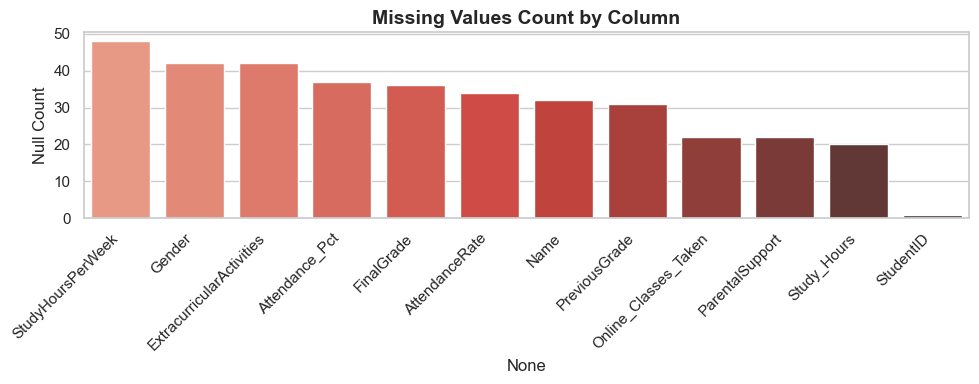

In [11]:
plt.figure(figsize=(10, 4))
sns.barplot(x=missing_df.index, y=missing_df['Missing_Count'], palette='Reds_d')
plt.title('Missing Values Count by Column', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Null Count')
plt.tight_layout()
plt.show()

### Imputation Strategy:
- **Numerical columns** (AttendanceRate, StudyHoursPerWeek, PreviousGrade, FinalGrade, etc.): Impute with **Median** to protect against skewness.
- **Categorical columns** (Gender, ParentalSupport, Online_Classes_Taken): Impute with **Mode** (most frequent class).
- **Identifier columns** (StudentID, Name): Impute with synthetic sequential IDs and 'Unknown'.

In [12]:
# 1. Impute StudentID and Name
df['StudentID'] = df['StudentID'].fillna(pd.Series(range(10000, 10000 + len(df)), index=df.index))
df['StudentID'] = df['StudentID'].astype(int)
df['Name'] = df['Name'].fillna('Unknown Student')

# 2. Impute Numerical Columns with Median
num_cols = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 
            'FinalGrade', 'Study_Hours', 'Attendance_Pct']

for col in num_cols:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'Imputed {col} with median: {median_val:.2f}')

# 3. Impute Categorical Columns with Mode
cat_cols = ['Gender', 'ParentalSupport', 'Online_Classes_Taken']
for col in cat_cols:
    if col in df.columns:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f'Imputed {col} with mode: {mode_val}')

# Verify all missing values are resolved
print(f'Remaining Missing Values in Dataset: {df.isnull().sum().sum()}')

Imputed AttendanceRate with median: 88.00
Imputed StudyHoursPerWeek with median: 17.00
Imputed PreviousGrade with median: 78.00
Imputed ExtracurricularActivities with median: 2.00
Imputed FinalGrade with median: 80.00
Imputed Study_Hours with median: 2.50
Imputed Attendance_Pct with median: 76.00
Imputed Gender with mode: Male
Imputed ParentalSupport with mode: High
Imputed Online_Classes_Taken with mode: True
Remaining Missing Values in Dataset: 0


## 6. Outlier Detection and Treatment (IQR Method)

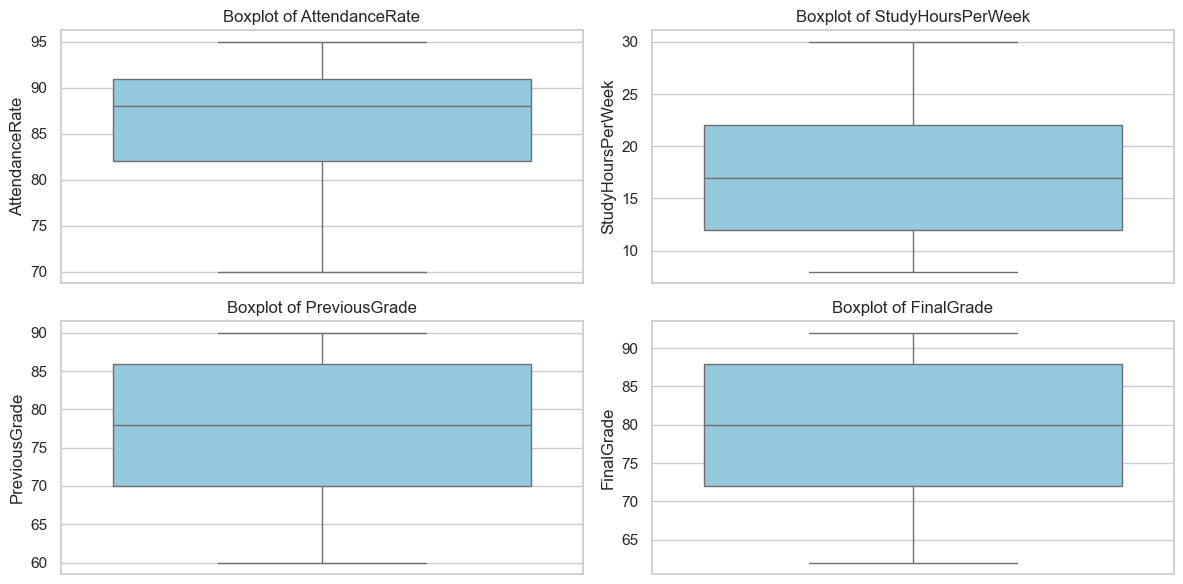

In [13]:
features_to_check = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'FinalGrade']

plt.figure(figsize=(12, 6))
for i, col in enumerate(features_to_check, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [14]:
for col in features_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers_before = ((df[col] < lower_limit) | (df[col] > upper_limit)).sum()
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)
    print(f'{col}: {outliers_before} outliers capped to [{lower_limit:.2f}, {upper_limit:.2f}]')

AttendanceRate: 0 outliers capped to [68.50, 104.50]
StudyHoursPerWeek: 0 outliers capped to [-3.00, 37.00]
PreviousGrade: 0 outliers capped to [46.00, 110.00]
FinalGrade: 0 outliers capped to [48.00, 112.00]


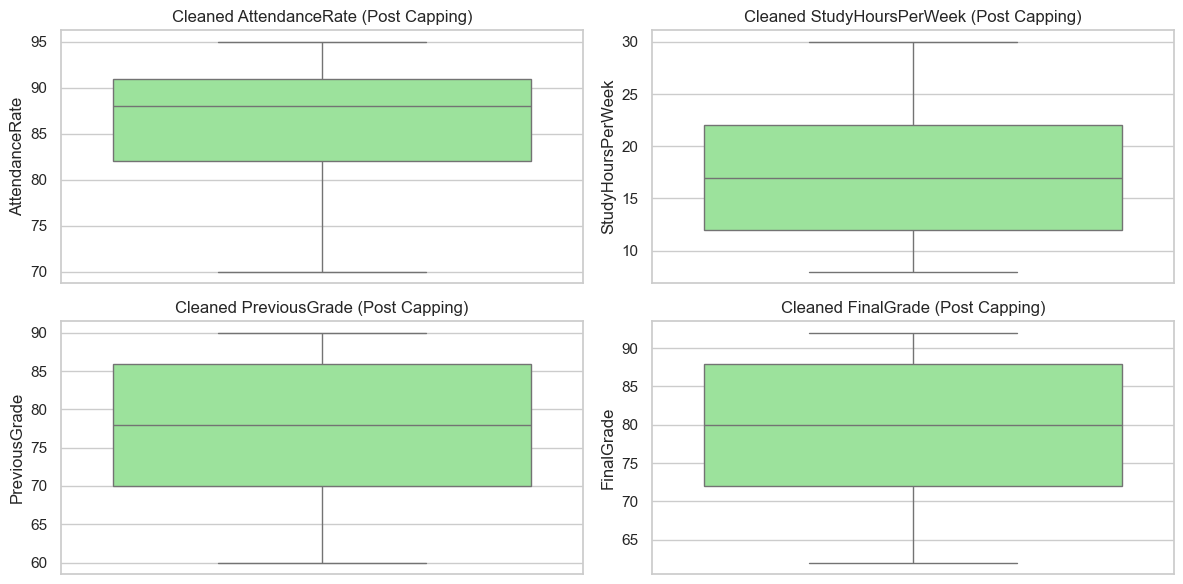

In [15]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(features_to_check, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Cleaned {col} (Post Capping)')
plt.tight_layout()
plt.show()

## 7. Machine Learning Feature Preprocessing (Encoding & Scaling)

In [16]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_ml = df.copy()

le_gender = LabelEncoder()
df_ml['Gender_Encoded'] = le_gender.fit_transform(df_ml['Gender'])

le_support = LabelEncoder()
df_ml['ParentalSupport_Encoded'] = le_support.fit_transform(df_ml['ParentalSupport'])

print('Label Encoding complete.')
df_ml[['Gender', 'Gender_Encoded', 'ParentalSupport', 'ParentalSupport_Encoded']].head()

Label Encoding complete.


,Gender,Gender_Encoded,ParentalSupport,ParentalSupport_Encoded
0,Male,1,High,0
1,Female,0,Medium,2
2,Male,1,Low,1
3,Male,1,High,0
4,Female,0,Medium,2


## 8. Export Cleaned Dataset and Final Verification

In [17]:
print('=== Cleaned Dataset Summary ===')
print(f'Shape: {df.shape}')
print(f'Total Nulls: {df.isnull().sum().sum()}')
print(f'Total Duplicates: {df.duplicated().sum()}')
print('\nSample Cleaned Data:')
print(df.head())

output_filename = 'cleaned_student_performance.csv'
df.to_csv(output_filename, index=False)
print(f'\nSuccessfully exported cleaned dataset to: {output_filename}')

=== Cleaned Dataset Summary ===
Shape: (917, 12)
Total Nulls: 0
Total Duplicates: 0

Sample Cleaned Data:
   StudentID     Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0       8998     John    Male            85.0               15.0   
1       5638    Sarah  Female            90.0               20.0   
2       8783     Alex    Male            78.0               10.0   
3       9867  Michael    Male            92.0               25.0   
4      87549     Emma  Female            88.0               18.0   

   PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  \
0           78.0                        1.0            High        80.0   
1           85.0                        2.0          Medium        87.0   
2           65.0                        0.0             Low        68.0   
3           90.0                        3.0            High        92.0   
4           82.0                        2.0          Medium        85.0   

   Study_Hours  Attendance_Pct Onl